In [ ]:
import os
print(os.getcwd())
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from torchvision import models
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


if os.path.isdir('/content/drive'):
    print("Directory exists")


/content


In [ ]:
# Google Drive mounten
from google.colab import drive
drive.mount('/content/drive')

# GPU prüfen
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU!")

Mounted at /content/drive
GPU: Tesla T4


In [ ]:
class NpyDataset(Dataset):
    def __init__(self, X_path, y_path):
        X = np.load(X_path)  # (N, H, W, C)
        y = np.load(y_path)
        print(y_path)
        print("unique labels:", np.unique(y), "count:", len(y))

        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]          # (H, W, C)
        x = x.permute(2, 0, 1)   # -> (C, H, W) channels-first [web:133][web:135]
        return x, self.y[idx]

train_ds = NpyDataset("/content/drive/MyDrive/Brain_Tumor_project/preprocessed/train_X.npy", "/content/drive/MyDrive/Brain_Tumor_project/preprocessed/train_y.npy")
test_ds  = NpyDataset("/content/drive/MyDrive/Brain_Tumor_project/preprocessed/test_X.npy",  "/content/drive/MyDrive/Brain_Tumor_project/preprocessed/test_y.npy")

test_full_len = len(test_ds)
val_len = test_full_len // 2
test_len = test_full_len - val_len

val_ds, final_test_ds = random_split(
    test_ds,
    lengths=[val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

print("Val size:", len(val_ds))
print("Final test size:", len(final_test_ds))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(final_test_ds,  batch_size=32, shuffle=False)

num_classes = 4

/content/drive/MyDrive/Brain_Tumor_project/preprocessed/train_y.npy
unique labels: [0 1 2 3] count: 10604
/content/drive/MyDrive/Brain_Tumor_project/preprocessed/test_y.npy
unique labels: [0 1 2 3] count: 2652
Val size: 1326
Final test size: 1326


In [ ]:
# 2. Model: pretrained ResNet-50 + new 4-class head
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features  # 1280 by B0

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.20),
    nn.Linear(512, num_classes)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


In [ ]:
# 3. Freeze backbone (baseline = feature extractor)
for name, param in model.named_parameters():
    if not name.startswith("classifier."):
        param.requires_grad = False
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

# Adjust LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
x_batch, y_batch = next(iter(train_loader))
print("Batch shape:", x_batch.shape, y_batch.shape)
print("Device:", device)

Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])
Device: cuda


In [ ]:
# 4. Training + validation loop (baseline)
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

checkpoint_dir = "/content/drive/MyDrive/CS659 Project/checkpoints/test"
os.makedirs(checkpoint_dir, exist_ok=True)

best_checkpoint_path = os.path.join(checkpoint_dir, "efficientnet_best.pt")

if os.path.isfile(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_val_acc = checkpoint.get("val_acc", -float("inf"))
    print(f"Found checkpoint. best_val_acc = {best_val_acc:.4f}")
else:
    best_val_acc = -float("inf")  # or use +inf with val_loss if you monitor loss
    print("No best checkpoint found. Starting fresh.")

No best checkpoint found. Starting fresh.


In [ ]:
# RUN IF STARTING TRAINING, OTHERWISE SKIP
num_epochs = 30
start_epoch = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

training_start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader,   criterion)

    scheduler.step(val_loss)  # Adjusts LR if val_loss plateaued

    epoch_time = time.time() - epoch_start

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch+1)%5 == 0:
      print(f"Epoch {epoch+1:02d}: "
            f"(time={epoch_time:.1f}s): "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

      ckpt_path = os.path.join(checkpoint_dir, f"resnet_epoch_{epoch+1}.pt")
      torch.save({
          "epoch": epoch + 1,
          "model_state": model.state_dict(),
          "optimizer_state": optimizer.state_dict(),
          "train_loss": train_loss,
          "val_loss": val_loss,
          "train_acc": train_acc,
          "val_acc": val_acc,
      }, ckpt_path)
      print(f"Saved checkpoint: {ckpt_path}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
          "epoch": epoch + 1,
          "model_state": model.state_dict(),
          "optimizer_state": optimizer.state_dict(),
          "train_loss": train_loss,
          "val_loss": val_loss,
          "train_acc": train_acc,
          "val_acc": val_acc,
      }, best_checkpoint_path)
      print(f"New best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

print(f"Total training time: {time.time() - training_start:.1f}s")

history = pd.DataFrame({
    "epoch": list(range(1, num_epochs + 1)),
    "train_loss": train_losses,
    "train_acc": train_accuracies,
    "val_loss": val_losses,
    "val_acc": val_accuracies,
})

results_dir = "/content/drive/MyDrive/Brain_Tumor_project/results/test"
os.makedirs(results_dir, exist_ok=True)

history.to_csv(Path(results_dir) / "efficientnet_history.csv", index=False)
print("Saved training history to CSV.")

New best model at epoch 1 with val_acc=0.9201
New best model at epoch 2 with val_acc=0.9382
New best model at epoch 3 with val_acc=0.9472
New best model at epoch 4 with val_acc=0.9525
Epoch 05: (time=19.2s): train_loss=0.5058, train_acc=0.938, val_loss=0.4659, val_acc=0.957
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/test/resnet_epoch_5.pt
New best model at epoch 5 with val_acc=0.9570
New best model at epoch 6 with val_acc=0.9646
New best model at epoch 7 with val_acc=0.9668
Epoch 10: (time=19.7s): train_loss=0.4600, train_acc=0.965, val_loss=0.4405, val_acc=0.968
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/test/resnet_epoch_10.pt
New best model at epoch 10 with val_acc=0.9683
New best model at epoch 11 with val_acc=0.9736
New best model at epoch 14 with val_acc=0.9789
Epoch 15: (time=19.4s): train_loss=0.4451, train_acc=0.974, val_loss=0.4400, val_acc=0.972
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/test/resnet_epoc

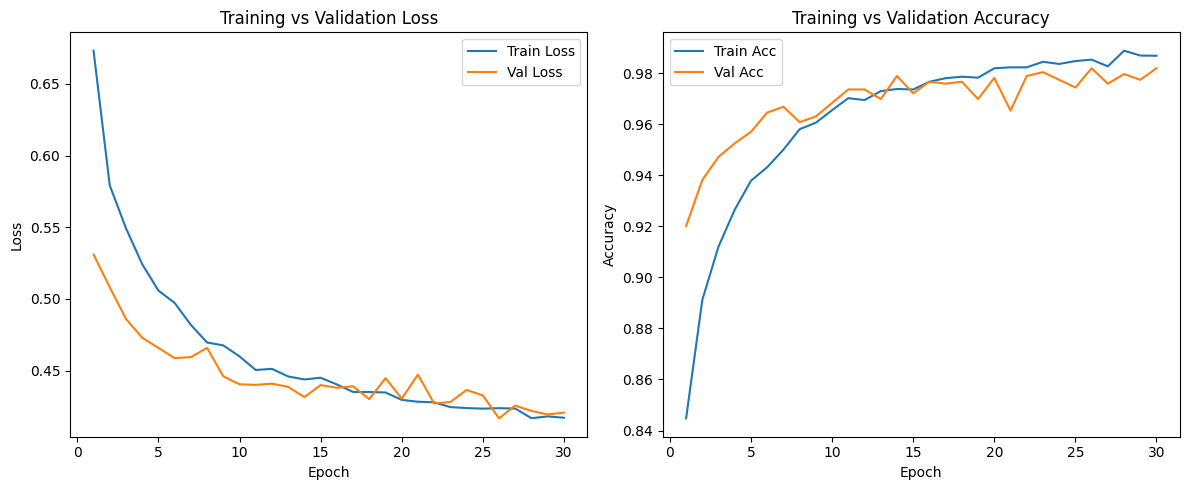

In [ ]:
history_path = "/content/drive/MyDrive/Brain_Tumor_project/results/test/efficientnet_history.csv"

# Load full history from CSV
history = pd.read_csv(history_path)

# Extract columns
epochs        = history["epoch"]
train_losses  = history["train_loss"]
val_losses    = history["val_loss"]
train_accs    = history["train_acc"]
val_accs      = history["val_acc"]


plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs,   label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Brain_Tumor_project/results/test/efficientnet_history.png')
plt.show()

In [ ]:
# Testing
# Load checkpoint
ckpt = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
print("Loaded model from checkpoint at epoch", ckpt["epoch"])

model.eval()

Loaded model from checkpoint at epoch 26


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Test Accuracy: 0.9819
Test Macro Precision: 0.9848
Test Macro Recall:    0.9817
Test Macro F1-score:  0.9832
Saved test results from best epoch 30 to CSV.


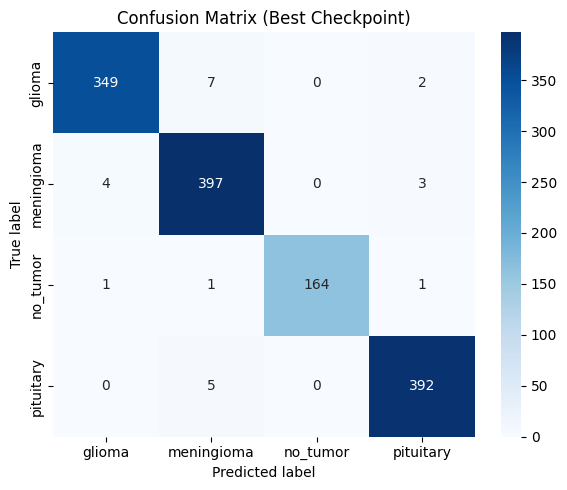

In [ ]:
all_preds = []
all_targets = []
img_save_dir = "/content/drive/MyDrive/Brain_Tumor_project/results/example_preds"
os.makedirs(img_save_dir, exist_ok=True)

saved = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

        for i in range(x.size(0)):
            if saved >= 20:   # limit to 20 examples
                break

            img = x[i].cpu()  # (C,H,W)
            pred = int(preds[i].cpu())
            true = int(y[i].cpu())

            # unnormalize if you used ImageNet normalization
            # img = img * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)
            img = img.permute(1, 2, 0).numpy()  # (H,W,C)

            plt.figure(figsize=(3,3))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Pred: {pred}, True: {true}")
            out_path = os.path.join(img_save_dir, f"example_{saved:03d}_pred{pred}_true{true}.png")
            plt.savefig(out_path, bbox_inches="tight")
            plt.close()
            saved += 1

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]  # or whatever your real names are
labels = np.array([0, 1, 2, 3])

# Metrics
acc = accuracy_score(all_targets, all_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    all_targets, all_preds, average='macro'
)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro Precision: {prec_macro:.4f}")
print(f"Test Macro Recall:    {rec_macro:.4f}")
print(f"Test Macro F1-score:  {f1_macro:.4f}")

test_results = pd.DataFrame({
    "best_epoch": [ckpt["epoch"]],
    "accuracy": [acc],
    "precision": [prec_macro],
    "F1_score": [f1_macro]
})

test_results.to_csv("/content/drive/MyDrive/Brain_Tumor_project/results/test_results.csv", index=False)
print(f"Saved test results from best epoch {ckpt['epoch']} to CSV.")

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in labels],
            yticklabels=[class_names[i] for i in labels])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Best Checkpoint)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Brain_Tumor_project/results/test_confusion_matrix.png')
plt.show()